# Рыночная структура и география


Цель данного ноутбука - проверить, как цена, доступность и пространственное распределение объявлений связаны с масштабом хоста и внутренней структурой рынка.


## Загрузка библиотек и установка настроек


In [11]:
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("viridis")
pd.set_option("display.float_format", "{:.4f}".format)


## Загрузка аналитического набора данных


In [12]:
listings = pd.read_parquet("../data/processed/listings_analytics.parquet")


## Проверка гипотез


### Гипотеза 1. Более крупные хосты удерживают более высокий ценовой уровень


0.233325372944444


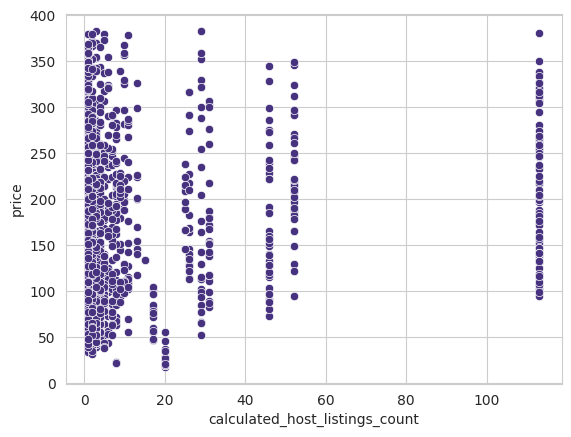

In [13]:
sns.scatterplot(
    data=listings,
    x="calculated_host_listings_count",
    y="price",
)

print(listings["calculated_host_listings_count"].corr(listings["price"]))


Вывод: Размер портфеля хоста умеренно влияет на ценовой слой, но не объясняет его полностью.


### Гипотеза 2. Более высокая доступность сопровождается более высокой ценой


0.17397387533849595


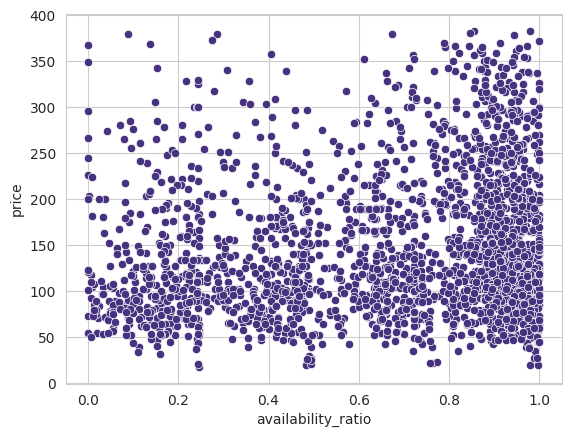

In [14]:
sns.scatterplot(
    data=listings,
    x="availability_ratio",
    y="price",
)

print(listings["availability_ratio"].corr(listings["price"]))


<Axes: xlabel='availability_segment', ylabel='price'>

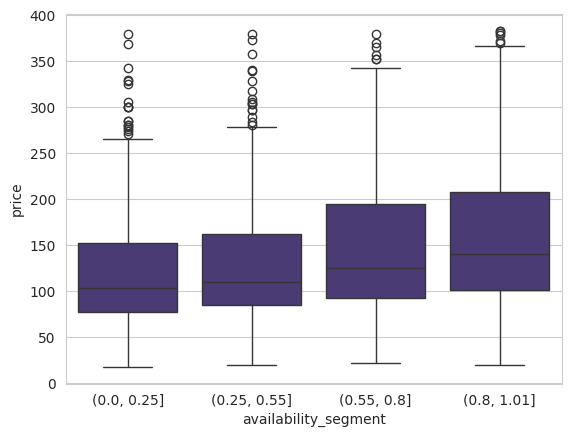

In [15]:
listings["availability_segment"] = pd.cut(
    listings["availability_ratio"], bins=[0, 0.25, 0.55, 0.8, 1.01]
)

sns.boxplot(data=listings, x="availability_segment", y="price")


<Axes: xlabel='availability_segment', ylabel='price'>

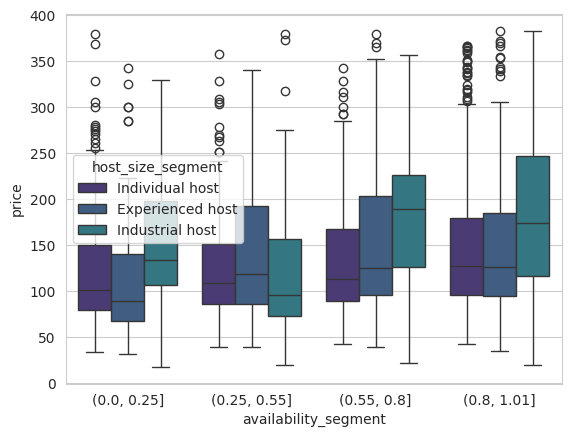

In [16]:
sns.boxplot(
    data=listings,
    x="availability_segment",
    y="price",
    hue="host_size_segment",
)


Вывод: При переходе от низкой доступности к высокой медиана `price` растёт, однако этот эффект заметен скорее как фоновая тенденция.


### Гипотеза 3. Более короткий минимальный срок аренды связан с более высокой ценой


-0.063871795258379


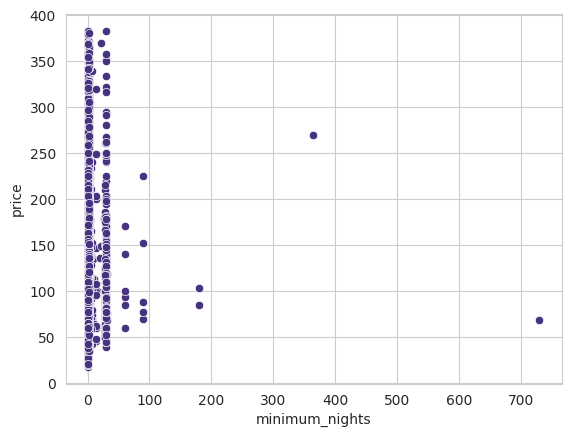

In [17]:
sns.scatterplot(
    data=listings,
    x="minimum_nights",
    y="price",
)

print(listings["minimum_nights"].corr(listings["price"]))


Вывод: Минимальный срок бронирования почти не объясняет различия в ценовом уровне.


### Гипотеза 4. Пропуски цены и ценовые выбросы зависят от сегмента хоста


/tmp/ipykernel_5941/3865470647.py:32: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(0, plot_long["rate"].max() * 1.15)


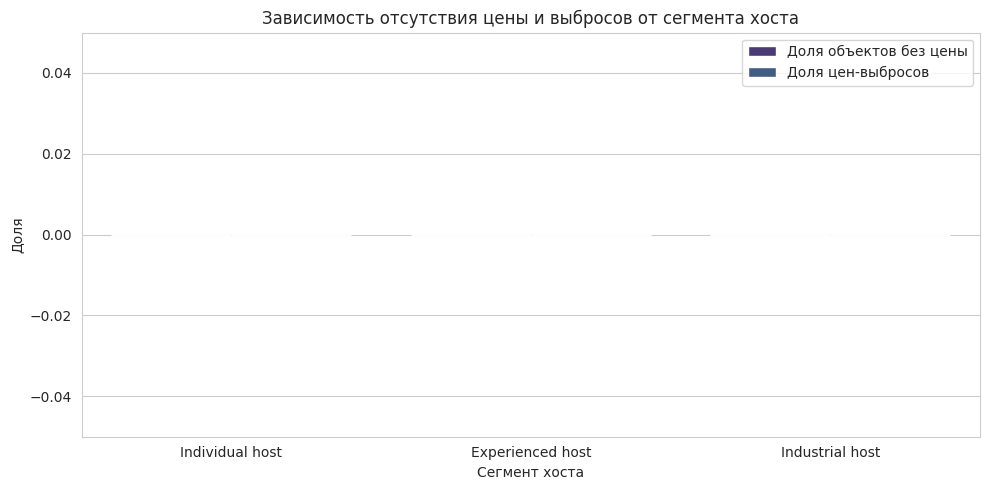

In [18]:
plot_df = (
    listings.groupby("host_size_segment", observed=False)
    .agg(
        missing_price_rate=("has_price", lambda x: 1 - x.mean()),
        outlier_rate=("is_price_outlier", "mean"),
        n=("id", "count"),
    )
    .reset_index()
)

plot_long = plot_df.melt(
    id_vars=["host_size_segment", "n"],
    value_vars=["missing_price_rate", "outlier_rate"],
    var_name="metric",
    value_name="rate",
)

metric_labels = {
    "missing_price_rate": "Доля объектов без цены",
    "outlier_rate": "Доля цен-выбросов",
}
plot_long["metric"] = plot_long["metric"].map(metric_labels)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=plot_long, x="host_size_segment", y="rate", hue="metric", errorbar=None
)

plt.title("Зависимость отсутствия цены и выбросов от сегмента хоста")
plt.xlabel("Сегмент хоста")
plt.ylabel("Доля")
plt.ylim(0, plot_long["rate"].max() * 1.15)
plt.legend(title="")
plt.tight_layout()
plt.show()


Вывод: По мере роста масштаба доля объявлений без цены снижается. Это означает, что крупные игроки реже скрывают цену, но заметно чаще работают в верхнем ценовом хвосте.


### Гипотеза 5. Крупные и мелкие хосты различаются по доступности объектов


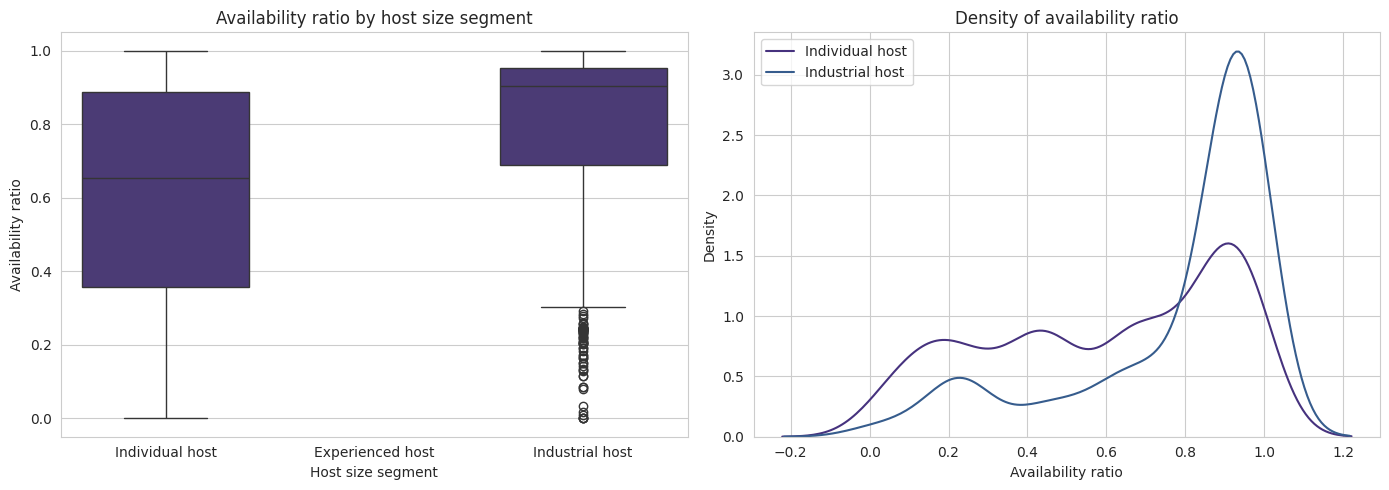

In [19]:
plot_df = listings.loc[
    listings["host_size_segment"].isin(["Individual host", "Industrial host"]),
    ["host_size_segment", "availability_ratio"],
].dropna()

individual = plot_df.loc[
    plot_df["host_size_segment"] == "Individual host", "availability_ratio"
]
industrial = plot_df.loc[
    plot_df["host_size_segment"] == "Industrial host", "availability_ratio"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=plot_df,
    x="host_size_segment",
    y="availability_ratio",
    ax=axes[0],
)
axes[0].set_title("Availability ratio by host size segment")
axes[0].set_xlabel("Host size segment")
axes[0].set_ylabel("Availability ratio")

sns.kdeplot(x=individual, ax=axes[1], label="Individual host")
sns.kdeplot(x=industrial, ax=axes[1], label="Industrial host")
axes[1].set_title("Density of availability ratio")
axes[1].set_xlabel("Availability ratio")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()


Вывод: Крупные хосты в среднем держат объекты доступными дольше и формируют более высокий запас предложения.


### Гипотеза 6. География предложения и спроса различается по типу владельца


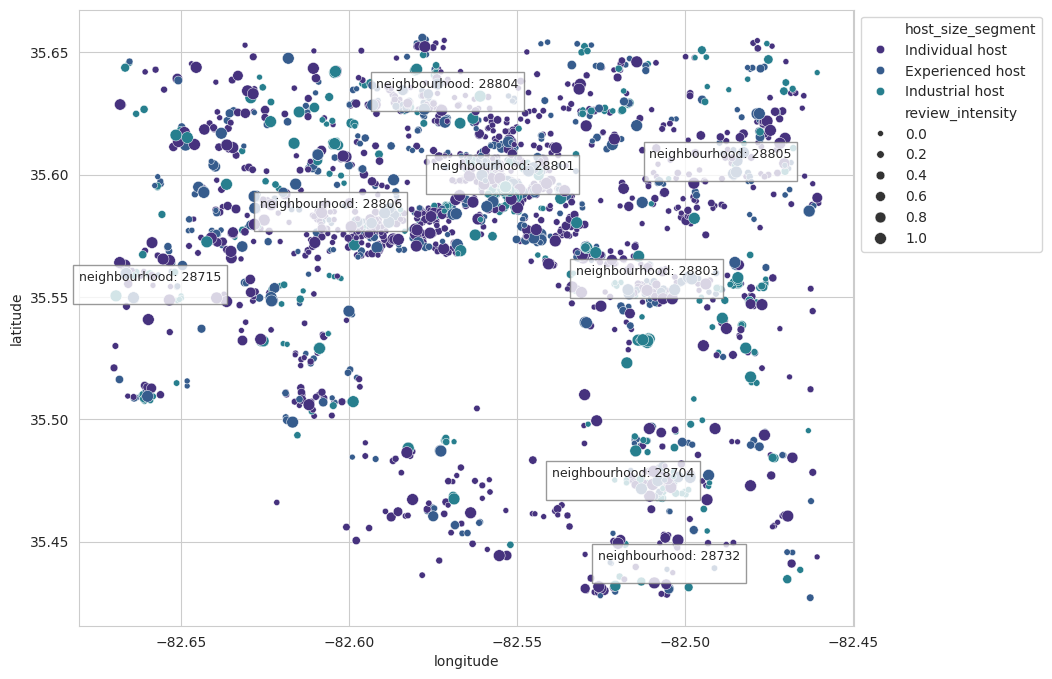

In [20]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=listings,
    x="longitude",
    y="latitude",
    size="review_intensity",
    hue="host_size_segment",
)

plt.legend(bbox_to_anchor=(1, 1))

centers = (
    listings.groupby("neighbourhood")
    .agg(
        {
            "longitude": "median",
            "latitude": "median",
        }
    )
    .reset_index()
)

for _, row in centers.iterrows():
    plt.text(
        row["longitude"],
        row["latitude"],
        f"neighbourhood: {int(row['neighbourhood'])}\n",
        fontsize=9,
        ha="center",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="grey"),
    )



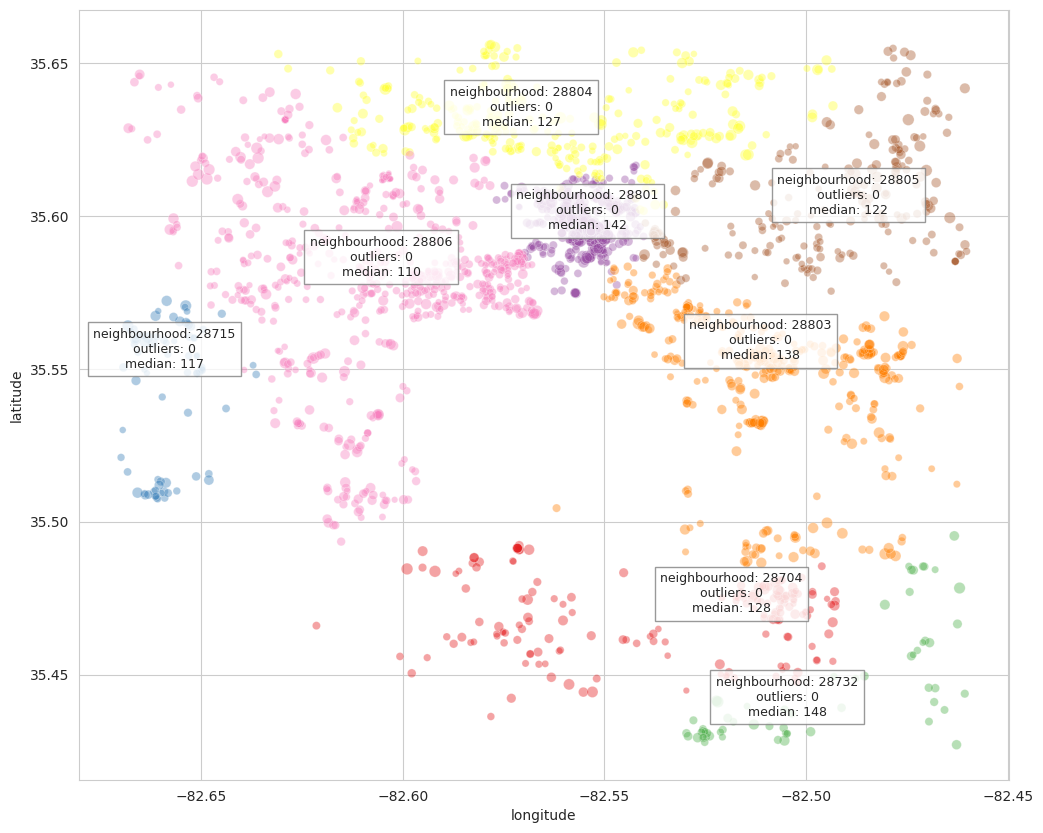

In [21]:
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x="longitude",
    y="latitude",
    hue="neighbourhood",
    palette="Set1",
    size="price",
    data=listings.sort_values("neighbourhood"),
    alpha=0.4,
    legend=False,
)

centers = (
    listings.groupby("neighbourhood")
    .agg(
        {
            "longitude": "median",
            "latitude": "median",
            "price": "median",
            "is_price_outlier": "sum",
        }
    )
    .reset_index()
)

for _, row in centers.iterrows():
    plt.text(
        row["longitude"],
        row["latitude"],
        f"neighbourhood: {int(row['neighbourhood'])}\noutliers: {int(row['is_price_outlier'])}\nmedian: {int(row['price'])}",
        fontsize=9,
        ha="center",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="grey"),
    )


Вывод: Индустриальный сегмент особенно заметен в `28801`, тогда как в `28805` и `28806` сильнее представлены индивидуальные хосты.  
Почти во всех зонах крупные игроки удерживают более высокую медианную цену, а наибольшее число ценовых выбросов наблюдается в `28806` и `28801`.


## Промежуточные выводы
1. Размер хоста связан с ценой заметно сильнее, чем `minimum_nights`, но даже эта связь остаётся лишь умеренной.
2. Более крупные игроки реже скрывают цену, но чаще попадают в верхний ценовой хвост и держат объекты доступными большую часть года.
3. Центральные и насыщенные зоны вроде `28801` сильнее представлены индустриальным сегментом и удерживают более высокий ценовой уровень.
